# Multimodal Emotion Recognition under Realistic Evaluation: Insights from IEMOCAP

## 1. Introduction
Speech Emotion Recognition (SER) systems can report high performance under random train-test splits. However, such results may be overly optimistic when speaker-specific cues leak between training and evaluation partitions. In that case, models can partially learn *who is speaking* rather than *what emotion is being expressed*.

This concern emerged clearly in our previous RAVDESS study, where performance decreased under speaker-independent validation. Building on that observation, the present work investigates whether multimodal modeling (audio + text) improves robustness when evaluation is explicitly speaker-aware.

This report is designed as an analysis-driven study rather than a score-maximization exercise. The objective is to explain not only *which* setup performs best, but also *why* specific gains appear or disappear across protocols.

### 1.1 Study Objective
To assess whether multimodal fusion provides meaningful and stable improvements over audio-only baselines on IEMOCAP under realistic speaker-aware evaluation.

### 1.2 Research Questions
- How sensitive are conclusions to the evaluation protocol?
- Does multimodal fusion consistently outperform strong audio baselines?
- Which errors remain dominant even after adding text information?
- What do the observed results imply for practical SER system design?

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import iemocap_pipeline as iemocap_pipeline
importlib.reload(iemocap_pipeline)

EMOTION_ID_TO_NAME = iemocap_pipeline.EMOTION_ID_TO_NAME
audit_dataset = iemocap_pipeline.audit_dataset
build_central_dataframe = iemocap_pipeline.build_central_dataframe
classification_report_dataframe = iemocap_pipeline.classification_report_dataframe
compare_standard_vs_group_split = iemocap_pipeline.compare_standard_vs_group_split
compute_factor_metrics = iemocap_pipeline.compute_factor_metrics
dataset_overview_table = iemocap_pipeline.dataset_overview_table
encode_labels = iemocap_pipeline.encode_labels
evaluate_models_with_groupkfold = iemocap_pipeline.evaluate_models_with_groupkfold
evaluate_tfidf_modalities_with_groupkfold = iemocap_pipeline.evaluate_tfidf_modalities_with_groupkfold
find_most_confused_pairs = iemocap_pipeline.find_most_confused_pairs
fuse_feature_blocks = iemocap_pipeline.fuse_feature_blocks
log_results_to_mlflow = iemocap_pipeline.log_results_to_mlflow
run_group_random_search = iemocap_pipeline.run_group_random_search
stack_feature_column = iemocap_pipeline.stack_feature_column
summarize_cv_results = iemocap_pipeline.summarize_cv_results
train_simple_audio_cnn = iemocap_pipeline.train_simple_audio_cnn

RANDOM_STATE = 42

print('Project root:', PROJECT_ROOT)

Project root: c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis


## 2. Dataset and Problem Context

We use the KaggleHub release of IEMOCAP, where each utterance is associated with aligned acoustic features, transcript text, emotion label, speaker identifier, and contextual metadata (gender and dialogue type). Compared with RAVDESS, IEMOCAP includes higher conversational variability and more natural emotional expression, making it a stronger testbed for real-world generalization.

### 2.1 Data Integrity Verification
The audit confirms that the working table is clean and fully usable:
- Samples before audit: **7433**
- Samples after audit: **7433**
- Removed samples: **0**
- Distinct speakers: **10**
- Dialogues: **151**
- Dialogue types: **3967 improvised**, **3466 scripted**
- Gender distribution: **3939 male**, **3494 female**
- Logged issues: **no_issues_detected**

These checks are essential because they isolate modeling effects from preprocessing artifacts.

## 3. Exploratory Analysis
The exploratory stage reveals moderate imbalance and substantial conversational diversity across speakers and dialogue conditions. This has direct methodological implications: without grouped evaluation, performance can be misinterpreted due to overlap in speaker-dependent patterns rather than true emotion generalization.

In [2]:
metadata = build_central_dataframe(download_if_missing=True)
metadata_clean, issue_summary, issue_log = audit_dataset(metadata)
overview = dataset_overview_table(metadata_clean)

print(f'Total samples before audit : {len(metadata)}')
print(f'Total samples after audit  : {len(metadata_clean)}')
print(f'Samples removed            : {len(metadata) - len(metadata_clean)}')
print(f'Number of speakers         : {metadata_clean["speaker_id"].nunique()}')
print(f'Number of dialogues        : {metadata_clean["dialogue_id"].nunique()}')
print('Emotion classes            :', sorted(metadata_clean['emotion'].unique()))
print()
print('Note: the KaggleHub bundle exposes aligned features and transcripts directly; no local data/ directory is created.')
print('Because raw file paths are not distributed in this compact release, `audio_path` is intentionally left missing.')

display(overview)
display(issue_summary)

metadata_clean[[
    'sample_id',
    'speaker_id',
    'gender',
    'emotion',
    'intensity',
    'transcript',
    'audio_path',
]].head()

Total samples before audit : 7433
Total samples after audit  : 7433
Samples removed            : 0
Number of speakers         : 10
Number of dialogues        : 151
Emotion classes            : ['angry', 'excited', 'frustrated', 'happy', 'neutral', 'sad']

Note: the KaggleHub bundle exposes aligned features and transcripts directly; no local data/ directory is created.
Because raw file paths are not distributed in this compact release, `audio_path` is intentionally left missing.


,num_samples,num_dialogues,num_speakers,num_emotions,avg_transcript_length_words,median_transcript_length_words
0,7433,151,10,6,11.99,9.0


,reason,count
0,no_issues_detected,0


,sample_id,speaker_id,gender,emotion,intensity,transcript,audio_path
0,Ses01F_impro01_F000,Ses01_F,female,neutral,unknown,Excuse me.,<NA>
1,Ses01F_impro01_F001,Ses01_F,female,neutral,unknown,Yeah.,<NA>
2,Ses01F_impro01_F002,Ses01_F,female,neutral,unknown,Is there a problem?,<NA>
3,Ses01F_impro01_F005,Ses01_F,female,neutral,unknown,Well what's the problem? Let me change it.,<NA>
4,Ses01F_impro01_F006,Ses01_F,female,frustrated,unknown,What? I'm getting an ID. This is why I'm her...,<NA>


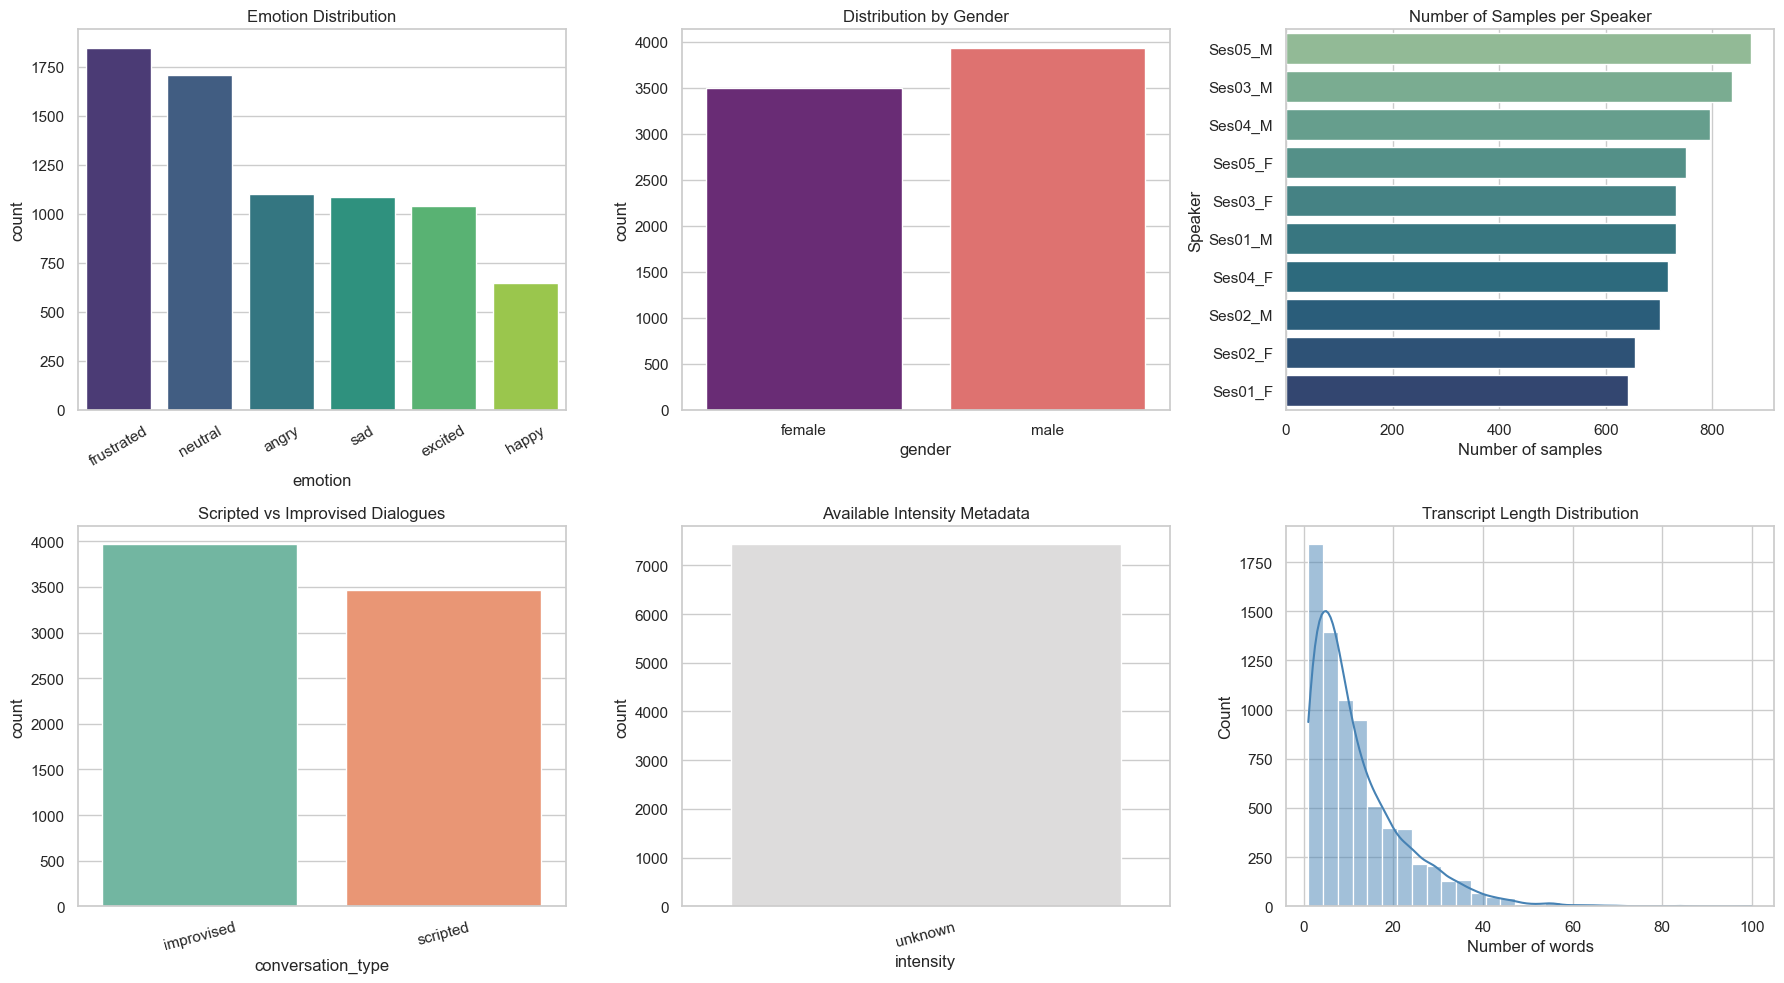

gender,female,male
emotion,,
angry,589,514
excited,443,598
frustrated,820,1029
happy,352,296
neutral,733,975
sad,557,527


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

emotion_order = metadata_clean['emotion'].value_counts().index
sns.countplot(data=metadata_clean, x='emotion', order=emotion_order, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Emotion Distribution')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.countplot(data=metadata_clean, x='gender', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Distribution by Gender')

speaker_counts = metadata_clean['speaker_id'].value_counts().sort_values(ascending=False)
sns.barplot(x=speaker_counts.values, y=speaker_counts.index, palette='crest', ax=axes[0, 2])
axes[0, 2].set_title('Number of Samples per Speaker')
axes[0, 2].set_xlabel('Number of samples')
axes[0, 2].set_ylabel('Speaker')

sns.countplot(data=metadata_clean, x='conversation_type', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Scripted vs Improvised Dialogues')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.countplot(data=metadata_clean, x='intensity', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Available Intensity Metadata')
axes[1, 1].tick_params(axis='x', rotation=15)

sns.histplot(data=metadata_clean, x='transcript_length_words', bins=30, kde=True, color='steelblue', ax=axes[1, 2])
axes[1, 2].set_title('Transcript Length Distribution')
axes[1, 2].set_xlabel('Number of words')

plt.tight_layout()
plt.show()

metadata_clean.groupby(['emotion', 'gender']).size().unstack(fill_value=0)

## 4. Methodology and Design Choices

### 4.1 Modalities and Representations
Three modality settings are evaluated:
- audio-only,
- text-only,
- multimodal (audio + text).

Audio is represented by concatenated precomputed acoustic blocks (`audio_features` + `auxiliary_features`). Text is represented through:
- TF-IDF (lexical baseline),
- dense embeddings (semantic baseline),
- stronger transformer-based embeddings in the extended stage.

### 4.2 Why These Fusion Strategies?
Each fusion strategy addresses a specific hypothesis:
- **Early fusion (concatenation):** useful cross-modal information is directly separable in a joint feature space.
- **Adaptive weighted late fusion:** modality reliability may vary across samples, so score-level weighting can improve decision calibration.
- **Cross-modal interaction fusion:** multiplicative and distance-based interactions may capture complementary structure missed by simple concatenation.

Using multiple fusion families prevents overfitting conclusions to one fusion mechanism.

### 4.3 Model Choices
- **Random Forest:** strong non-linear classical baseline with class balancing.
- **MLP:** high-capacity discriminative baseline with scaling and early stopping.
- **Lightweight 1D CNN (audio vectors):** deep baseline included for comparison, not as a fully optimized end-to-end temporal model.

## 5. Experimental Setup

### 5.1 Evaluation Protocols
We use speaker-aware protocols throughout the core analysis:
- **GroupKFold (k=5):** stable grouped estimate.
- **Leave-One-Speaker-Out (LOSO):** strict speaker-level transfer evaluation.

### 5.2 Metrics
- Accuracy
- Balanced Accuracy
- Macro F1

Macro F1 is emphasized to better reflect class-balanced performance.

### 5.3 Hyperparameter Selection
Hyperparameters are tuned with group-aware cross-validation. This avoids leakage during model selection and preserves the validity of protocol comparisons.

In [3]:
y_encoded, label_encoder = encode_labels(metadata_clean['emotion'])
class_names = list(label_encoder.classes_)
groups = metadata_clean['speaker_id'].to_numpy()
texts = metadata_clean['transcript'].fillna('').tolist()

X_audio_base = stack_feature_column(metadata_clean, 'audio_features')
X_audio_extended = np.hstack([
    X_audio_base,
    stack_feature_column(metadata_clean, 'auxiliary_features'),
])
X_text_dense = stack_feature_column(metadata_clean, 'dense_features')
X_multimodal_dense = fuse_feature_blocks(X_audio_extended, X_text_dense)

print('Audio base shape       :', X_audio_base.shape)
print('Audio extended shape   :', X_audio_extended.shape)
print('Text dense shape       :', X_text_dense.shape)
print('Multimodal dense shape :', X_multimodal_dense.shape)
print('Number of speakers     :', len(np.unique(groups)))
print('Emotion classes        :', class_names)

split_audio_df, split_audio_details = compare_standard_vs_group_split(
    X_audio_extended,
    y_encoded,
    groups,
    random_state=RANDOM_STATE,
)
split_multi_df, split_multi_details = compare_standard_vs_group_split(
    X_multimodal_dense,
    y_encoded,
    groups,
    random_state=RANDOM_STATE,
)

split_audio_df['modality'] = 'Audio only'
split_multi_df['modality'] = 'Audio + dense text'
split_comparison = pd.concat([split_audio_df, split_multi_df], ignore_index=True)
split_comparison = split_comparison[[
    'modality',
    'split',
    'model',
    'train_accuracy',
    'accuracy',
    'balanced_accuracy',
    'macro_f1',
]].sort_values(['modality', 'split', 'macro_f1'], ascending=[True, True, False])

split_comparison

Audio base shape       : (7433, 100)
Audio extended shape   : (7433, 200)
Text dense shape       : (7433, 512)
Multimodal dense shape : (7433, 712)
Number of speakers     : 10
Emotion classes        : [np.str_('angry'), np.str_('excited'), np.str_('frustrated'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


,modality,split,model,train_accuracy,accuracy,balanced_accuracy,macro_f1
4,Audio + dense text,Approach 1 — Standard stratified split,MLP,0.874706,0.826496,0.823560,0.829390
5,Audio + dense text,Approach 1 — Standard stratified split,RandomForest,1.000000,0.811029,0.807150,0.817011
6,Audio + dense text,Approach 2 — Speaker-independent group split,RandomForest,1.000000,0.721510,0.715583,0.710743
7,Audio + dense text,Approach 2 — Speaker-independent group split,MLP,0.900000,0.714767,0.708231,0.703082
0,Audio only,Approach 1 — Standard stratified split,MLP,0.869828,0.815064,0.813478,0.819613
1,Audio only,Approach 1 — Standard stratified split,RandomForest,0.999159,0.799597,0.793185,0.803563
2,Audio only,Approach 2 — Speaker-independent group split,MLP,0.871597,0.710722,0.707439,0.698857
3,Audio only,Approach 2 — Speaker-independent group split,RandomForest,0.999328,0.707350,0.697448,0.695001


In [4]:
metrics_audio, preds_audio = evaluate_models_with_groupkfold(
    X_audio_extended,
    y_encoded,
    groups,
    modality_name='Audio only',
    random_state=RANDOM_STATE,
    n_splits=5,
)
metrics_text_dense, preds_text_dense = evaluate_models_with_groupkfold(
    X_text_dense,
    y_encoded,
    groups,
    modality_name='Text dense only',
    random_state=RANDOM_STATE,
    n_splits=5,
)
metrics_multi_dense, preds_multi_dense = evaluate_models_with_groupkfold(
    X_multimodal_dense,
    y_encoded,
    groups,
    modality_name='Audio + dense text',
    random_state=RANDOM_STATE,
    n_splits=5,
)

metrics_text_tfidf, preds_text_tfidf = evaluate_tfidf_modalities_with_groupkfold(
    texts,
    y_encoded,
    groups,
    modality_name='Text TF-IDF',
    audio_block=None,
    random_state=RANDOM_STATE,
    n_splits=5,
    max_features=2000,
)
metrics_multi_tfidf, preds_multi_tfidf = evaluate_tfidf_modalities_with_groupkfold(
    texts,
    y_encoded,
    groups,
    modality_name='Audio + TF-IDF',
    audio_block=X_audio_extended,
    random_state=RANDOM_STATE,
    n_splits=5,
    max_features=2000,
)

all_metrics = pd.concat(
    [metrics_audio, metrics_text_dense, metrics_multi_dense, metrics_text_tfidf, metrics_multi_tfidf],
    ignore_index=True,
)
all_predictions = pd.concat(
    [preds_audio, preds_text_dense, preds_multi_dense, preds_text_tfidf, preds_multi_tfidf],
    ignore_index=True,
)

cv_summary = summarize_cv_results(all_metrics)
display(cv_summary)

rf_search = run_group_random_search(
    'RandomForest',
    X_multimodal_dense,
    y_encoded,
    groups,
    n_iter=8,
    n_splits=5,
    random_state=RANDOM_STATE,
)
mlp_search = run_group_random_search(
    'MLP',
    X_multimodal_dense,
    y_encoded,
    groups,
    n_iter=8,
    n_splits=5,
    random_state=RANDOM_STATE,
)

tuning_summary = pd.DataFrame([
    {
        'model': 'RandomForest',
        'best_macro_f1_cv': rf_search.best_score_,
        'best_params': rf_search.best_params_,
    },
    {
        'model': 'MLP',
        'best_macro_f1_cv': mlp_search.best_score_,
        'best_params': mlp_search.best_params_,
    },
])

display(tuning_summary)

_ = log_results_to_mlflow(
    experiment_name='IEMOCAP Phase 2',
    run_name='multimodal_dense_search_snapshot',
    metrics={
        'rf_best_macro_f1': rf_search.best_score_,
        'mlp_best_macro_f1': mlp_search.best_score_,
    },
    params={
        'dataset_source': 'kagglehub:columbine/iemocap',
        'protocol': 'GroupKFold speaker-independent',
    },
    tags={'phase': 'phase2', 'study': 'multimodal-emotion-recognition'},
)

train_accuracy         accuracy          \
                                          mean     std     mean     std   
modality           model                                                  
Audio + TF-IDF     MLP                  0.9199  0.0333   0.7943  0.1072   
                   RandomForest         0.9993  0.0002   0.8183  0.1160   
Audio + dense text MLP                  0.9178  0.0312   0.8161  0.1223   
                   RandomForest         1.0000  0.0000   0.8250  0.1188   
Audio only         MLP                  0.8515  0.0218   0.8289  0.1216   
                   RandomForest         0.9993  0.0002   0.8165  0.1158   
Text TF-IDF        MLP                  0.8320  0.0186   0.4629  0.0164   
                   RandomForest         0.9122  0.0049   0.4766  0.0248   
Text dense only    MLP                  0.6022  0.0444   0.4128  0.0639   
                   RandomForest         0.9323  0.0089   0.4240  0.0534   

                                balanced_accuracy         macro_f1          \
                                             mean     std     mean     std   
modality           model                                                     
Audio + TF-IDF     MLP                     0.7902  0.1147   0.7910  0.1108   
                   RandomForest            0.8112  0.1247   0.8162  0.1197   
Audio + dense text MLP                     0.8102  0.1240   0.8119  0.1272   
                   RandomForest            0.8164  0.1286   0.8227  0.1237   
Audio only         MLP                     0.8220  0.1281   0.8257  0.1256   
                   RandomForest            0.8103  0.1254   0.8140  0.1199   
Text TF-IDF        MLP                     0.4526  0.0126   0.4508  0.0152   
                   RandomForest            0.4580  0.0220   0.4643  0.0251   
Text dense only    MLP                     0.3930  0.0402   0.3897  0.0518   
                   RandomForest            0.3906  0.0411   0.3901  0.0445   

                                precision_macro         recall_macro          
                                           mean     std         mean     std  
modality           model                                                      
Audio + TF-IDF     MLP                   0.7978  0.1059       0.7902  0.1147  
                   RandomForest          0.8256  0.1110       0.8112  0.1247  
Audio + dense text MLP                   0.8202  0.1254       0.8102  0.1240  
                   RandomForest          0.8334  0.1145       0.8164  0.1286  
Audio only         MLP                   0.8343  0.1182       0.8220  0.1281  
                   RandomForest          0.8216  0.1111       0.8103  0.1254  
Text TF-IDF        MLP                   0.4686  0.0164       0.4526  0.0126  
                   RandomForest          0.4909  0.0248       0.4580  0.0220  
Text dense only    MLP                   0.4345  0.0597       0.3930  0.0402  
                   RandomForest          0.4519  0.0431       0.3906  0.0411

,model,best_macro_f1_cv,best_params
0,RandomForest,0.834339,"{'n_estimators': 200, 'min_samples_split': 10,..."
1,MLP,0.825917,"{'mlp__learning_rate_init': 0.0001, 'mlp__hidd..."


## 6. Results and Quantitative Interpretation

### 6.1 Protocol Effect: Optimistic vs Speaker-Aware Evaluation
A major finding is the magnitude of protocol sensitivity.

For **Audio-only (MLP)**:
- Standard split macro F1: **0.8196**
- Speaker-independent group split macro F1: **0.6989**
- Absolute change: **-0.1208**

For **Audio + dense text (MLP)**:
- Standard split macro F1: **0.8294**
- Speaker-independent group split macro F1: **0.7031**
- Absolute change: **-0.1263**

Interpretation: random splits materially inflate expected performance. Both configurations benefit from speaker-correlated information under standard splitting, which can mask true generalization difficulty.

### 6.2 GroupKFold Baseline Results
From `iemocap_experiment_summary.csv`, the strongest GroupKFold settings are:
1. Audio only + MLP: **0.8257** macro F1
2. Audio + dense text + RandomForest: **0.8227** macro F1
3. Audio + TF-IDF + RandomForest: **0.8162** macro F1

Text-only settings remain substantially lower:
- Text TF-IDF + RandomForest: **0.4643**
- Text dense only + RandomForest: **0.3901**

Interpretation: acoustic features contain the dominant emotion signal in this pipeline. Text adds contextual cues, but does not independently recover strong discriminative boundaries.

### 6.3 Extended Fusion and LOSO Results
From `iemocap_extended_fusion_comparison.csv`:
- Best GroupKFold score: **Adaptive weighted late fusion + MLP = 0.8262**
- Best LOSO score: **Audio only (LOSO) + MLP = 0.8222**
- Best multimodal LOSO score: **Adaptive weighted late fusion (LOSO) + MLP = 0.8165**

Effect-size interpretation:
- Best multimodal gain over best audio in GroupKFold: **+0.0005**
- Best multimodal relative to best audio in LOSO: **-0.0056**

Interpretation: multimodal fusion is competitive but not consistently superior under strict speaker holdout. Gains are small and not protocol-invariant, which limits immediate practical advantage.

### 6.4 Error Structure
The confusion profile is dominated by adjacent affective classes (especially neutral/frustrated and happy/excited). This indicates that future progress likely depends on boundary-focused disambiguation rather than generic feature expansion.

Saved experiment summary to: c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis\iemocap_experiment_summary.csv


,modality,model,accuracy,balanced_accuracy,macro_f1
4,Audio only,MLP,0.828864,0.821956,0.825700
3,Audio + dense text,RandomForest,0.825006,0.816377,0.822658
1,Audio + TF-IDF,RandomForest,0.818269,0.811181,0.816242
5,Audio only,RandomForest,0.816516,0.810273,0.814007
2,Audio + dense text,MLP,0.816072,0.810171,0.811863
0,Audio + TF-IDF,MLP,0.794265,0.790205,0.791010
7,Text TF-IDF,RandomForest,0.476613,0.458003,0.464263
6,Text TF-IDF,MLP,0.462934,0.452613,0.450760
9,Text dense only,RandomForest,0.424050,0.390557,0.390121
8,Text dense only,MLP,0.412840,0.393040,0.389682


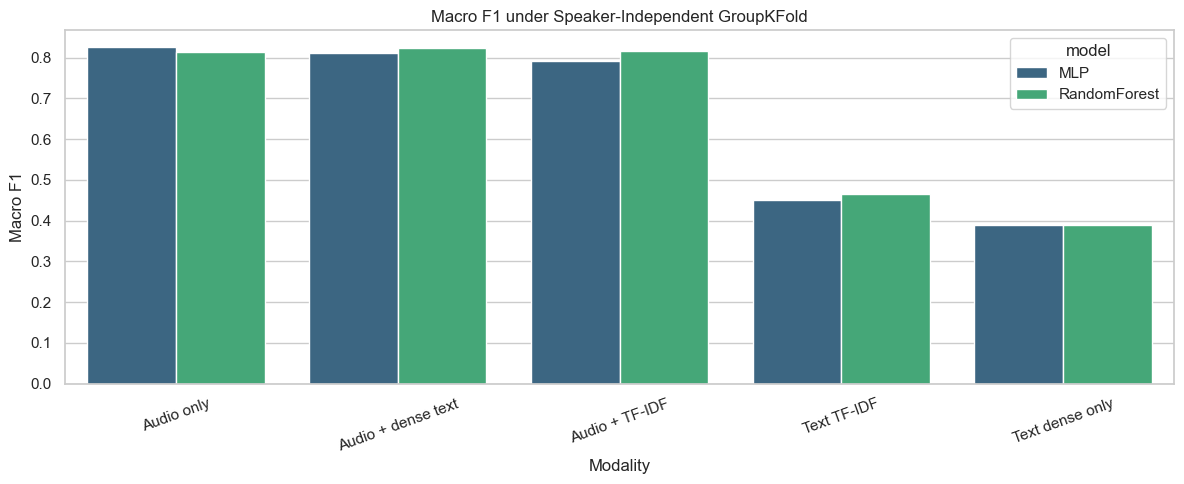

Saved figure to: c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis\iemocap_groupkfold_model_comparison.png
Best modality: Audio only
Best model   : MLP


,precision,recall,f1-score,support
angry,0.864220,0.854034,0.859097,1103.000000
excited,0.825750,0.819404,0.822565,1041.000000
frustrated,0.804903,0.852353,0.827949,1849.000000
happy,0.846975,0.734568,0.786777,648.000000
neutral,0.796286,0.803279,0.799767,1708.000000
sad,0.880975,0.867159,0.874012,1084.000000
accuracy,0.828602,0.828602,0.828602,0.828602
macro avg,0.836518,0.821799,0.828361,7433.000000
weighted avg,0.829407,0.828602,0.828469,7433.000000


,true_label,predicted_label,count
0,neutral,frustrated,158
1,frustrated,neutral,118
2,angry,frustrated,109
3,frustrated,angry,92
4,happy,excited,83
5,excited,neutral,78
6,neutral,sad,70
7,sad,neutral,68
8,sad,frustrated,58
9,happy,neutral,52


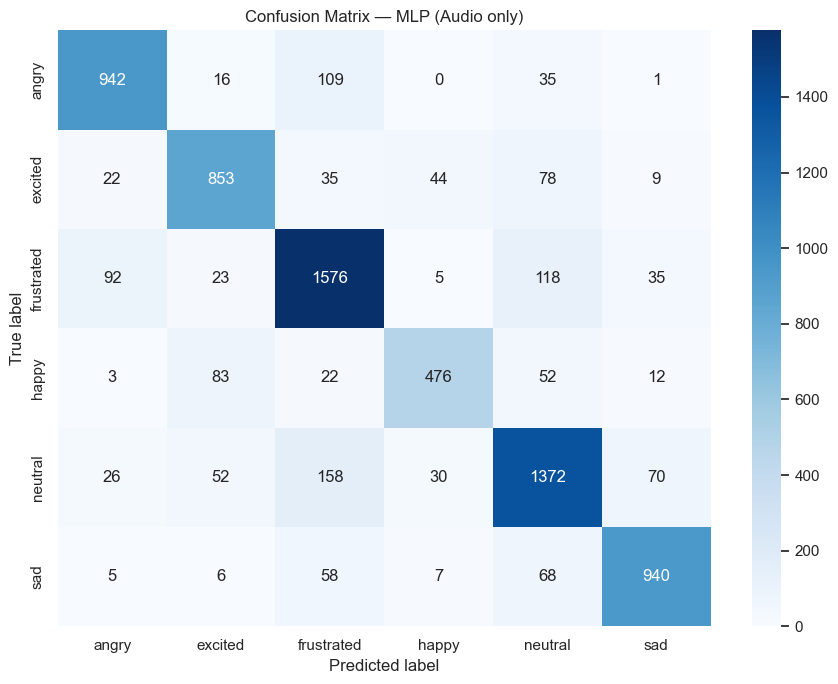

Saved confusion matrix to: c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis\iemocap_best_confusion_matrix.png


,modality,model,gender,num_samples,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
1,Audio + TF-IDF,MLP,male,3939,0.799695,0.786738,0.794766,0.805738,0.786738
0,Audio + TF-IDF,MLP,female,3494,0.787922,0.785649,0.787927,0.791226,0.785649
3,Audio + TF-IDF,RandomForest,male,3939,0.828383,0.815273,0.826686,0.841361,0.815273
2,Audio + TF-IDF,RandomForest,female,3494,0.806525,0.800860,0.806936,0.814630,0.800860
5,Audio + dense text,MLP,male,3939,0.822036,0.809194,0.813641,0.821476,0.809194
4,Audio + dense text,MLP,female,3494,0.808815,0.809287,0.808401,0.808894,0.809287
7,Audio + dense text,RandomForest,male,3939,0.834983,0.820149,0.833548,0.851014,0.820149
6,Audio + dense text,RandomForest,female,3494,0.813394,0.808831,0.814436,0.821641,0.808831
9,Audio only,MLP,male,3939,0.834476,0.820171,0.832833,0.849043,0.820171
8,Audio only,MLP,female,3494,0.821981,0.822341,0.822109,0.824509,0.822341


,modality,model,conversation_type,num_samples,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,Audio + TF-IDF,MLP,improvised,3967,0.807159,0.785633,0.792438,0.802496,0.785633
1,Audio + TF-IDF,MLP,scripted,3466,0.779284,0.775537,0.776692,0.778246,0.775537
2,Audio + TF-IDF,RandomForest,improvised,3967,0.823544,0.802584,0.815702,0.834514,0.802584
3,Audio + TF-IDF,RandomForest,scripted,3466,0.811887,0.806535,0.810348,0.816147,0.806535
5,Audio + dense text,MLP,scripted,3466,0.819965,0.814440,0.819181,0.826488,0.814440
4,Audio + dense text,MLP,improvised,3967,0.812201,0.795642,0.796362,0.798806,0.795642
6,Audio + dense text,RandomForest,improvised,3967,0.826317,0.804252,0.819311,0.840699,0.804252
7,Audio + dense text,RandomForest,scripted,3466,0.823139,0.818100,0.823255,0.831061,0.818100
8,Audio only,MLP,improvised,3967,0.829846,0.812561,0.821181,0.835312,0.812561
9,Audio only,MLP,scripted,3466,0.827178,0.823051,0.825842,0.829585,0.823051


,modality,model,speaker_id,num_samples,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
2,Audio + TF-IDF,MLP,Ses02_F,654,0.908257,0.916198,0.908311,0.905065,0.916198
7,Audio + TF-IDF,MLP,Ses04_M,796,0.888191,0.896307,0.887634,0.884858,0.896307
3,Audio + TF-IDF,MLP,Ses02_M,702,0.874644,0.875487,0.872012,0.874486,0.875487
5,Audio + TF-IDF,MLP,Ses03_M,837,0.872162,0.872250,0.874867,0.880209,0.872250
4,Audio + TF-IDF,MLP,Ses03_F,732,0.845628,0.850444,0.845645,0.847757,0.850444
1,Audio + TF-IDF,MLP,Ses01_M,732,0.844262,0.841924,0.834175,0.849528,0.841924
0,Audio + TF-IDF,MLP,Ses01_F,641,0.837754,0.845051,0.835968,0.828981,0.845051
6,Audio + TF-IDF,MLP,Ses04_F,716,0.831006,0.850494,0.812717,0.798341,0.850494
9,Audio + TF-IDF,MLP,Ses05_M,872,0.551606,0.543522,0.542043,0.565131,0.543522
8,Audio + TF-IDF,MLP,Ses05_F,751,0.543276,0.522719,0.520061,0.528906,0.522719


,modality,model,intensity,num_samples,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,Audio + TF-IDF,MLP,unknown,7433,0.794161,0.787384,0.792188,0.798141,0.787384
1,Audio + TF-IDF,RandomForest,unknown,7433,0.818108,0.808630,0.817662,0.828875,0.808630
2,Audio + dense text,MLP,unknown,7433,0.815821,0.809634,0.812543,0.816516,0.809634
3,Audio + dense text,RandomForest,unknown,7433,0.824835,0.815067,0.824665,0.836616,0.815067
4,Audio only,MLP,unknown,7433,0.828602,0.821799,0.828361,0.836518,0.821799
5,Audio only,RandomForest,unknown,7433,0.816359,0.807952,0.815529,0.824709,0.807952
6,Text TF-IDF,MLP,unknown,7433,0.463070,0.444146,0.452153,0.465795,0.444146
7,Text TF-IDF,RandomForest,unknown,7433,0.476793,0.453908,0.466287,0.490843,0.453908
8,Text dense only,MLP,unknown,7433,0.412485,0.398737,0.403921,0.412800,0.398737
9,Text dense only,RandomForest,unknown,7433,0.423920,0.396921,0.402361,0.444845,0.396921



CNN audio-only snapshot on a speaker-independent split:
            accuracy: 0.4026
   balanced_accuracy: 0.3677
            macro_f1: 0.3555
     precision_macro: 0.4862
        recall_macro: 0.3677


In [6]:
summary_reset = (
    all_metrics
    .groupby(['modality', 'model'])[['accuracy', 'balanced_accuracy', 'macro_f1']]
    .mean()
    .reset_index()
    .sort_values('macro_f1', ascending=False)
)

summary_path = PROJECT_ROOT / 'iemocap_experiment_summary.csv'
summary_reset.to_csv(summary_path, index=False)
print('Saved experiment summary to:', summary_path)
display(summary_reset)

plt.figure(figsize=(12, 5))
sns.barplot(data=summary_reset, x='modality', y='macro_f1', hue='model', palette='viridis')
plt.title('Macro F1 under Speaker-Independent GroupKFold')
plt.xlabel('Modality')
plt.ylabel('Macro F1')
plt.xticks(rotation=20)
plt.tight_layout()
plot_path = PROJECT_ROOT / 'iemocap_groupkfold_model_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure to:', plot_path)

best_row = summary_reset.iloc[0]
best_modality = best_row['modality']
best_model = best_row['model']

best_predictions = (
    all_predictions[
        (all_predictions['modality'] == best_modality)
        & (all_predictions['model'] == best_model)
    ]
    .sort_values('sample_index')
)

cm = confusion_matrix(best_predictions['y_true'], best_predictions['y_pred'])
report_df = classification_report_dataframe(
    best_predictions['y_true'],
    best_predictions['y_pred'],
    class_names,
)
analysis_df = pd.DataFrame(find_most_confused_pairs(cm, class_names, top_k=10))

print('Best modality:', best_modality)
print('Best model   :', best_model)
display(report_df)
display(analysis_df)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model} ({best_modality})')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_path = PROJECT_ROOT / 'iemocap_best_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion matrix to:', cm_path)

gender_analysis = compute_factor_metrics(metadata_clean, all_predictions, 'gender')
conversation_analysis = compute_factor_metrics(metadata_clean, all_predictions, 'conversation_type')
speaker_analysis = compute_factor_metrics(metadata_clean, all_predictions, 'speaker_id')
intensity_analysis = compute_factor_metrics(metadata_clean, all_predictions, 'intensity')

display(gender_analysis.sort_values(['modality', 'model', 'accuracy'], ascending=[True, True, False]))
display(conversation_analysis.sort_values(['modality', 'model', 'accuracy'], ascending=[True, True, False]))
display(speaker_analysis.sort_values(['modality', 'model', 'accuracy'], ascending=[True, True, False]).head(20))
display(intensity_analysis)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_audio_extended, y_encoded, groups=groups))
cnn_metrics, cnn_y_pred = train_simple_audio_cnn(
    X_audio_extended[train_idx],
    y_encoded[train_idx],
    X_audio_extended[test_idx],
    y_encoded[test_idx],
    random_state=RANDOM_STATE,
    epochs=15,
    batch_size=64,
)

print('\nCNN audio-only snapshot on a speaker-independent split:')
for metric_name, metric_value in cnn_metrics.items():
    print(f'{metric_name:>20}: {metric_value:.4f}')

## 7. Link with the RAVDESS Project

The previous RAVDESS study showed a strong performance decrease when moving from random splits to speaker-independent validation, highlighting leakage-driven optimism. IEMOCAP shows the same phenomenon in direction, but with dataset-specific magnitude and behavior.

This continuity is central to the project narrative:
- RAVDESS identified the methodological risk (speaker leakage).
- IEMOCAP tests whether multimodal information reduces that risk under more realistic conditions.
- The current results show that multimodal fusion does not automatically solve speaker-level generalization.

Why IEMOCAP behaves differently from RAVDESS:
- broader conversational variability reduces trivial memorization pathways,
- compact precomputed features may attenuate direct timbre dependence,
- less exaggerated emotional expression increases intrinsic task difficulty.

Therefore, the main transferable lesson across both projects is methodological: conclusions must be protocol-aware and effect-size based.

In [7]:
# Additional helpers for the robustness-oriented multimodal extension
build_sentence_embeddings = iemocap_pipeline.build_sentence_embeddings
build_transformer_cls_embeddings = iemocap_pipeline.build_transformer_cls_embeddings
evaluate_models_with_loso = iemocap_pipeline.evaluate_models_with_loso
evaluate_tfidf_modalities_with_loso = iemocap_pipeline.evaluate_tfidf_modalities_with_loso
evaluate_adaptive_weighted_fusion_with_groupkfold = iemocap_pipeline.evaluate_adaptive_weighted_fusion_with_groupkfold
evaluate_adaptive_weighted_fusion_with_loso = iemocap_pipeline.evaluate_adaptive_weighted_fusion_with_loso
evaluate_cross_modal_fusion_with_groupkfold = iemocap_pipeline.evaluate_cross_modal_fusion_with_groupkfold
evaluate_cross_modal_fusion_with_loso = iemocap_pipeline.evaluate_cross_modal_fusion_with_loso
evaluate_cnn_with_groupkfold = iemocap_pipeline.evaluate_cnn_with_groupkfold
evaluate_cnn_with_loso = iemocap_pipeline.evaluate_cnn_with_loso

# Stronger text encoder: Sentence-BERT first, transformer CLS second, existing dense features as a safe fallback
strong_text_model_name = 'sentence-transformers/all-mpnet-base-v2'
try:
    X_text_strong = build_sentence_embeddings(texts, model_name=strong_text_model_name)
    strong_text_label = 'Sentence-BERT (all-mpnet-base-v2)'
except Exception as sentence_exc:
    warnings.warn(f'Sentence-BERT encoding failed ({sentence_exc}). Falling back to transformer CLS embeddings.')
    cls_model_name = 'distilbert-base-uncased'
    try:
        X_text_strong = build_transformer_cls_embeddings(
            texts,
            model_name=cls_model_name,
            batch_size=32,
            max_length=128,
        )
        strong_text_label = f'Transformer CLS ({cls_model_name})'
    except Exception as cls_exc:
        warnings.warn(f'Transformer CLS encoding failed ({cls_exc}). Reusing the provided dense features instead.')
        X_text_strong = X_text_dense.copy()
        strong_text_label = 'Provided dense embeddings (fallback)'

print('Strong text representation:', strong_text_label)
print('Strong text shape         :', X_text_strong.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3080.87it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Strong text representation: Sentence-BERT (all-mpnet-base-v2)
Strong text shape         : (7433, 768)


In [8]:
# GroupKFold comparison across the extended fusion strategies
X_multimodal_strong = fuse_feature_blocks(X_audio_extended, X_text_strong)

metrics_strong_early, preds_strong_early = evaluate_models_with_groupkfold(
    X_multimodal_strong,
    y_encoded,
    groups,
    modality_name='Audio + strong text (early fusion)',
    random_state=RANDOM_STATE,
    n_splits=5,
)
metrics_weighted_late, preds_weighted_late, weighted_late_weights = evaluate_adaptive_weighted_fusion_with_groupkfold(
    X_audio_extended,
    X_text_strong,
    y_encoded,
    groups,
    modality_name='Adaptive weighted late fusion',
    random_state=RANDOM_STATE,
    n_splits=5,
    weight_grid=np.linspace(0.1, 0.9, 9),
)
metrics_cross_modal, preds_cross_modal = evaluate_cross_modal_fusion_with_groupkfold(
    X_audio_extended,
    X_text_strong,
    y_encoded,
    groups,
    modality_name='Cross-modal interaction fusion',
    random_state=RANDOM_STATE,
    n_splits=5,
    n_components=64,
)
metrics_cnn_group, preds_cnn_group = evaluate_cnn_with_groupkfold(
    X_audio_extended,
    y_encoded,
    groups,
    modality_name='Audio only (CNN)',
    random_state=RANDOM_STATE,
    n_splits=5,
    epochs=15,
    batch_size=64,
)

extended_group_metrics = pd.concat(
    [
        all_metrics,
        metrics_strong_early,
        metrics_weighted_late,
        metrics_cross_modal,
        metrics_cnn_group,
    ],
    ignore_index=True,
)
extended_group_predictions = pd.concat(
    [
        all_predictions,
        preds_strong_early,
        preds_weighted_late,
        preds_cross_modal,
        preds_cnn_group,
    ],
    ignore_index=True,
)

group_fusion_comparison = (
    extended_group_metrics
    .groupby(['modality', 'model'])[['accuracy', 'balanced_accuracy', 'macro_f1']]
    .mean()
    .reset_index()
    .sort_values('macro_f1', ascending=False)
)

print('GroupKFold comparison across all fusion strategies:')
display(group_fusion_comparison)

print('Average adaptive fusion weights selected on the validation folds:')
display(
    weighted_late_weights
    .groupby('model')[['selected_audio_weight', 'selected_text_weight', 'validation_macro_f1']]
    .mean()
    .round(4)
)

GroupKFold comparison across all fusion strategies:


,modality,model,accuracy,balanced_accuracy,macro_f1
0,Adaptive weighted late fusion,MLP,0.830214,0.822249,0.826215
8,Audio only,MLP,0.828864,0.821956,0.825700
5,Audio + dense text,RandomForest,0.825006,0.816377,0.822658
3,Audio + TF-IDF,RandomForest,0.818269,0.811181,0.816242
9,Audio only,RandomForest,0.816516,0.810273,0.814007
1,Adaptive weighted late fusion,RandomForest,0.815159,0.809104,0.813008
4,Audio + dense text,MLP,0.816072,0.810171,0.811863
12,Cross-modal interaction fusion,RandomForest,0.814644,0.805411,0.810719
7,Audio + strong text (early fusion),RandomForest,0.813143,0.806604,0.810529
6,Audio + strong text (early fusion),MLP,0.809800,0.807770,0.807983


Average adaptive fusion weights selected on the validation folds:


,selected_audio_weight,selected_text_weight,validation_macro_f1
model,,,
MLP,0.88,0.12,0.9027
RandomForest,0.90,0.10,0.8906


Saved extended comparison to: c:\Users\223114186\Downloads\Multimodal_Speech_&_Emotion_Analysis\iemocap_extended_fusion_comparison.csv


,protocol,modality,model,accuracy,balanced_accuracy,macro_f1
0,GroupKFold,Adaptive weighted late fusion,MLP,0.830214,0.822249,0.826215
1,GroupKFold,Audio only,MLP,0.828864,0.821956,0.825700
2,GroupKFold,Audio + dense text,RandomForest,0.825006,0.816377,0.822658
3,GroupKFold,Audio + TF-IDF,RandomForest,0.818269,0.811181,0.816242
4,GroupKFold,Audio only,RandomForest,0.816516,0.810273,0.814007
5,GroupKFold,Adaptive weighted late fusion,RandomForest,0.815159,0.809104,0.813008
6,GroupKFold,Audio + dense text,MLP,0.816072,0.810171,0.811863
7,GroupKFold,Cross-modal interaction fusion,RandomForest,0.814644,0.805411,0.810719
8,GroupKFold,Audio + strong text (early fusion),RandomForest,0.813143,0.806604,0.810529
9,GroupKFold,Audio + strong text (early fusion),MLP,0.809800,0.807770,0.807983


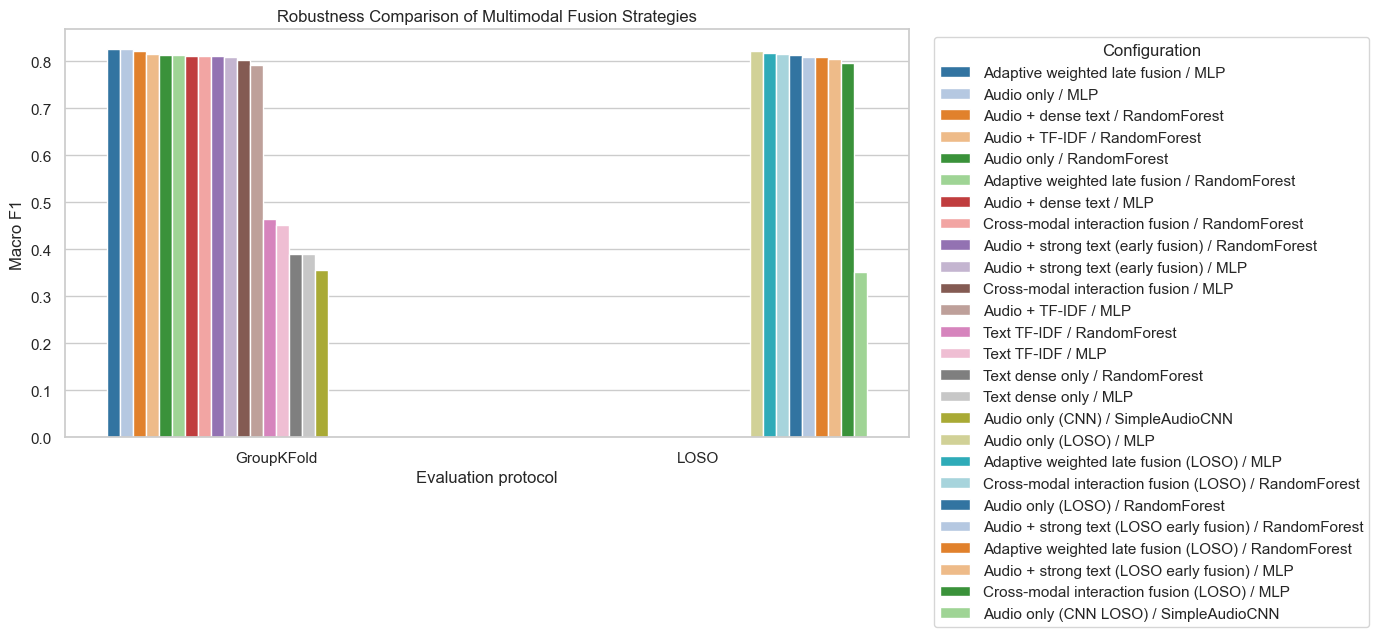

Average LOSO adaptive weights:


,selected_audio_weight,selected_text_weight,validation_macro_f1
model,,,
MLP,0.73,0.27,0.7449
RandomForest,0.74,0.26,0.7430


CNN-focused summary included in the global comparison:


,accuracy,balanced_accuracy,macro_f1
modality,,,
Audio only (CNN LOSO),0.4191,0.3740,0.3522
Audio only (CNN),0.4229,0.3745,0.3561


In [9]:
# LOSO evaluation and final robustness comparison table
metrics_audio_loso, preds_audio_loso = evaluate_models_with_loso(
    X_audio_extended,
    y_encoded,
    groups,
    modality_name='Audio only (LOSO)',
    random_state=RANDOM_STATE,
)
metrics_strong_early_loso, preds_strong_early_loso = evaluate_models_with_loso(
    X_multimodal_strong,
    y_encoded,
    groups,
    modality_name='Audio + strong text (LOSO early fusion)',
    random_state=RANDOM_STATE,
)
metrics_weighted_loso, preds_weighted_loso, weighted_loso_weights = evaluate_adaptive_weighted_fusion_with_loso(
    X_audio_extended,
    X_text_strong,
    y_encoded,
    groups,
    modality_name='Adaptive weighted late fusion (LOSO)',
    random_state=RANDOM_STATE,
    weight_grid=np.linspace(0.1, 0.9, 9),
)
metrics_cross_loso, preds_cross_loso = evaluate_cross_modal_fusion_with_loso(
    X_audio_extended,
    X_text_strong,
    y_encoded,
    groups,
    modality_name='Cross-modal interaction fusion (LOSO)',
    random_state=RANDOM_STATE,
    n_components=64,
)
metrics_cnn_loso, preds_cnn_loso = evaluate_cnn_with_loso(
    X_audio_extended,
    y_encoded,
    groups,
    modality_name='Audio only (CNN LOSO)',
    random_state=RANDOM_STATE,
    epochs=15,
    batch_size=64,
)

loso_metrics = pd.concat(
    [
        metrics_audio_loso,
        metrics_strong_early_loso,
        metrics_weighted_loso,
        metrics_cross_loso,
        metrics_cnn_loso,
    ],
    ignore_index=True,
)
loso_predictions = pd.concat(
    [
        preds_audio_loso,
        preds_strong_early_loso,
        preds_weighted_loso,
        preds_cross_loso,
        preds_cnn_loso,
    ],
    ignore_index=True,
)

loso_comparison = (
    loso_metrics
    .groupby(['modality', 'model'])[['accuracy', 'balanced_accuracy', 'macro_f1']]
    .mean()
    .reset_index()
    .sort_values('macro_f1', ascending=False)
)

group_table = group_fusion_comparison.copy()
group_table['protocol'] = 'GroupKFold'
loso_table = loso_comparison.copy()
loso_table['protocol'] = 'LOSO'

robustness_comparison = pd.concat([group_table, loso_table], ignore_index=True)
robustness_comparison = robustness_comparison[
    ['protocol', 'modality', 'model', 'accuracy', 'balanced_accuracy', 'macro_f1']
].sort_values(['protocol', 'macro_f1'], ascending=[True, False])

comparison_path = PROJECT_ROOT / 'iemocap_extended_fusion_comparison.csv'
robustness_comparison.to_csv(comparison_path, index=False)

print('Saved extended comparison to:', comparison_path)
display(robustness_comparison)

plt.figure(figsize=(14, 6))
plot_df = robustness_comparison.copy()
plot_df['fusion_label'] = plot_df['modality'] + ' / ' + plot_df['model']
sns.barplot(
    data=plot_df,
    x='protocol',
    y='macro_f1',
    hue='fusion_label',
    palette='tab20',
)
plt.title('Robustness Comparison of Multimodal Fusion Strategies')
plt.xlabel('Evaluation protocol')
plt.ylabel('Macro F1')
plt.legend(title='Configuration', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Average LOSO adaptive weights:')
display(
    weighted_loso_weights
    .groupby('model')[['selected_audio_weight', 'selected_text_weight', 'validation_macro_f1']]
    .mean()
    .round(4)
)

cnn_focus = pd.concat([metrics_cnn_group, metrics_cnn_loso], ignore_index=True)
print('CNN-focused summary included in the global comparison:')
display(
    cnn_focus
    .groupby('modality')[['accuracy', 'balanced_accuracy', 'macro_f1']]
    .mean()
    .round(4)
)

## 8. Discussion

### 8.1 Why Multimodal Gains Remain Limited in This Setup
1. **Indirect emotional content in transcripts**
Many utterances are short, context-dependent, and lexically ambiguous with respect to emotion.

2. **Dominance of acoustic emotion cues**
Prosody, energy dynamics, and spectral structure remain primary carriers of emotion information.

3. **Fusion depth remains moderate**
Early concatenation and lightweight interaction blocks may not capture higher-order cross-modal dependencies.

4. **Representation-task mismatch**
Generic semantic embeddings are not explicitly optimized for emotion discrimination.

### 8.2 What the Results Mean
The key contribution is evidential rigor: speaker-aware protocols, effect-size analysis, and class-level error interpretation are necessary to produce reliable SER conclusions. Multimodality should be evaluated by stable cross-speaker transfer, not isolated score peaks.

## 9. Conclusion
Two conclusions are strongly supported by the evidence:
- Evaluation protocol substantially changes performance interpretation.
- In this pipeline, multimodal fusion does not provide a stable advantage over strong audio baselines under strict speaker-aware testing.

These findings do not reject multimodal SER; they indicate that stronger representation alignment and more expressive fusion are required to obtain robust, reproducible gains.

## 10. Positioning with Recent Research

Recent research in multimodal emotion recognition converges on several trends that align with our observations:
- transformer-based cross-modal attention improves interaction modeling compared with simple concatenation,
- self-supervised speech representations (for example wav2vec2/HuBERT families) often strengthen acoustic transfer,
- modality-reliability and uncertainty-aware fusion are increasingly used to avoid over-trusting weak modalities,
- protocol rigor (speaker-independent and cross-session testing) is now emphasized over random split performance.

Representative lines of work include Multimodal Transformer-style fusion approaches, modality-invariant/specific representation learning, and recent benchmark studies that prioritize robust generalization reporting on corpora such as IEMOCAP.

Positioning of the present project:
- We are aligned with the current shift from score-centric reporting toward protocol-aware analysis.
- Our results reinforce recent findings that multimodal fusion is not inherently superior unless representation and fusion choices are well matched to the task.

## 11. Future Work
Priority directions for the next phase are:
- attention-based or gated fusion with explicit modality-reliability modeling,
- sequence-aware architectures (LSTM/Transformer) over temporally structured inputs,
- emotion-oriented fine-tuning of text encoders rather than generic semantic embeddings,
- per-speaker variance reporting in addition to mean scores,
- cross-dataset transfer studies to test external validity.

The immediate practical objective is to redesign multimodal interaction learning while preserving LOSO-style evaluation as the primary decision protocol.